# Naive Bayes

## Imports

### Import data

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/model-ready.csv')
df.head()

,ISRC,Genre,Track,Album Name,Artist,All Time Rank,Track Score,Spotify Streams,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,AirPlay Spins,Pandora Streams,Pandora Track Stations,Shazam Counts,Explicit Track,Length,Releases,Registration Country,Followers,TikTok Views per Post,TikTok Impact,TikTok View-to-Like Ratio,TikTok Likes per Post,YouTube View-to-Like Ratio,Shazam Conversion Rate,Days Since Release,Label Prob,Label
0,QM24S2402528,Other,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,1,725.4,390470936,92,84274754,1713126,5767700,651565900,5332281936,40975,18004655,22931,2669262,0,155.1510,1,United States,847504.0,924.507505,0.000011,8.183795,112.968044,49.193524,0.000493,344,0.734589,1
1,USUG12400910,Rap,Not Like Us,Not Like Us,Kendrick Lamar,2,545.9,323703884,92,116347040,3486739,674700,35223547,208339025,40778,7780028,28444,1118279,1,274.1920,5,United States,38589324.0,308.787646,0.000003,5.914765,52.206158,33.368430,0.003444,336,0.721077,1
2,QZJ842400387,Other,i like the way you kiss me,I like the way you kiss me,Artemas,3,538.4,601309283,92,122599116,2228730,3025400,275154237,3369120610,74333,5022621,5639,5285340,0,143.1865,8,United States,1133424.0,1113.611625,0.000009,12.244480,90.948022,55.008485,0.001514,382,0.771418,1
3,USSM12209777,Other,Flowers,Flowers - Single,Miley Cyrus,4,444.9,2031280633,85,1096100899,10629796,7189811,1078757968,14603725994,1474799,190260277,203384,11822942,0,200.4530,30,United States,25620499.0,2031.169664,0.000002,13.537537,150.039802,103.115883,0.000753,814,0.799485,1
4,USAT22311371,Other,Lovin On Me,Lovin On Me,Jack Harlow,6,410.1,670665438,83,131148091,1392593,4202367,214943489,2938686633,522042,138529362,50982,4517131,1,138.4110,13,United States,4106706.0,699.293192,0.000005,13.671903,51.148183,94.175396,0.001471,512,0.758437,1


### Import modules

For Naive Bayes, we use scikit-learn's MultinomialNB, GaussianNB, and CategoricalNB:
1. MultinomialNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB
2. GaussianNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB
3. CategoricalNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html#sklearn.naive_bayes.CategoricalNB

To interpret results, we use scikit-learn's ConfusionMatrixDisplay:
1. ConfusionMatrixDisplay: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

## Data Prep

### Custom functions to reduce code repetition

See file at `./custom_data_prep.py` for the code.

In [2]:
from custom_data_prep import (
    my_corr_plotter, my_binner, 
    my_count_binner, my_count_vectorizer, my_bin_plotter
)

### Feature selection

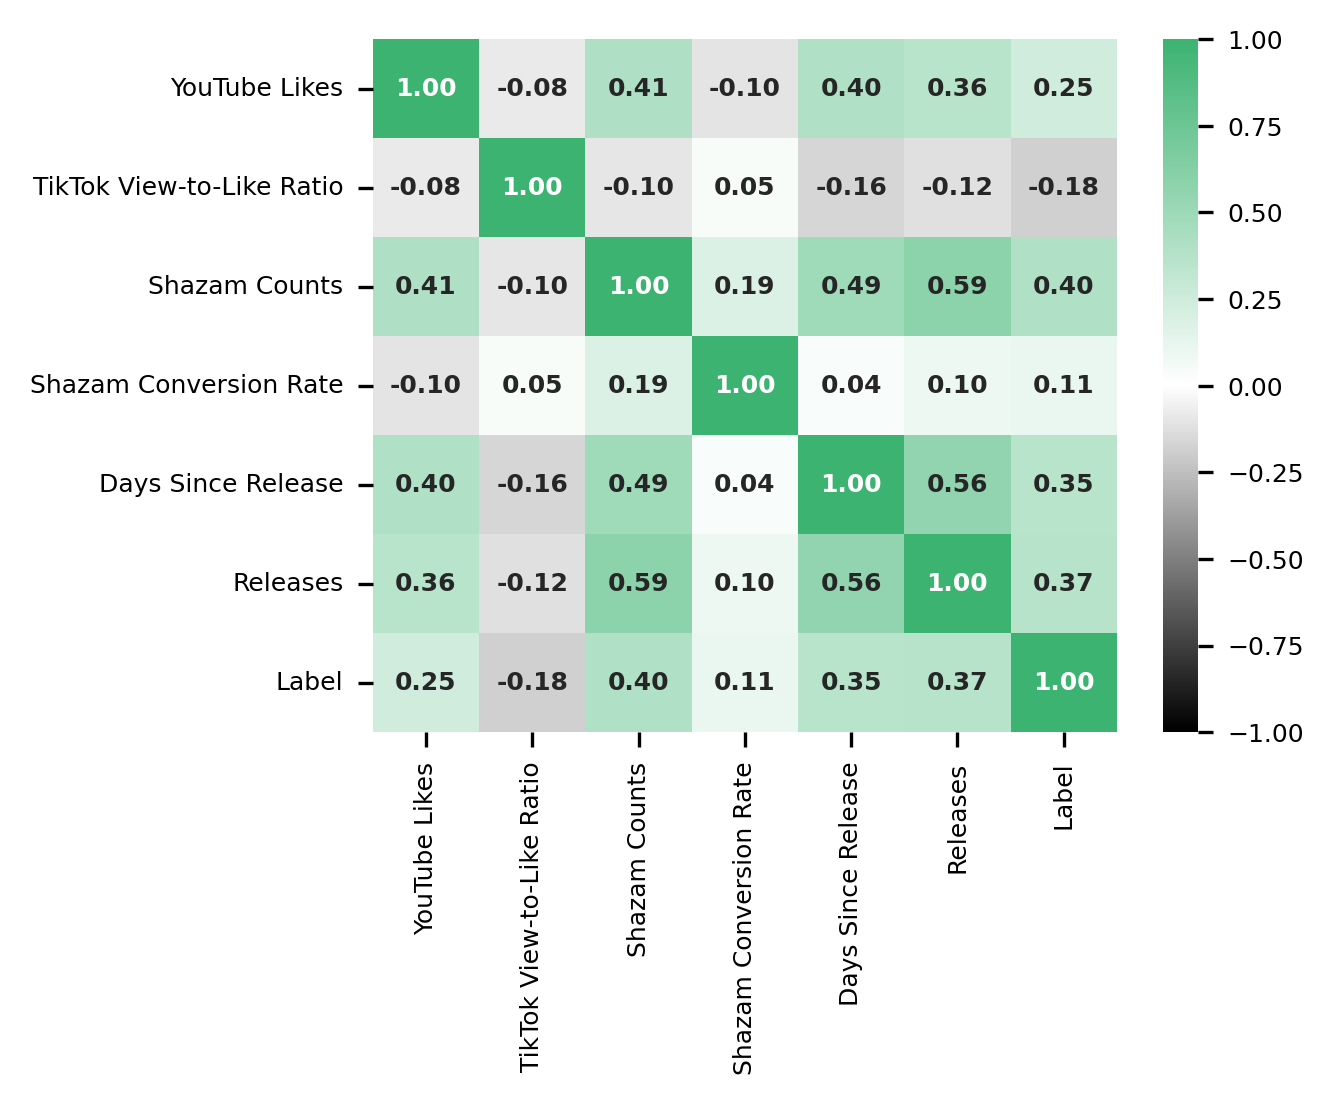

In [3]:
df_nb = df[['YouTube Likes',
            'TikTok View-to-Like Ratio', # TikTok Views / (TikTok Likes + 1)
            'Shazam Counts',
            'Shazam Conversion Rate', # Shazam Counts / (YouTube Views + TikTok Views + 1)
            'Days Since Release',
            'Releases',
            'Label']]
df_nb.head()

my_corr_plotter(df_nb)

### Multinomial Naive Bayes

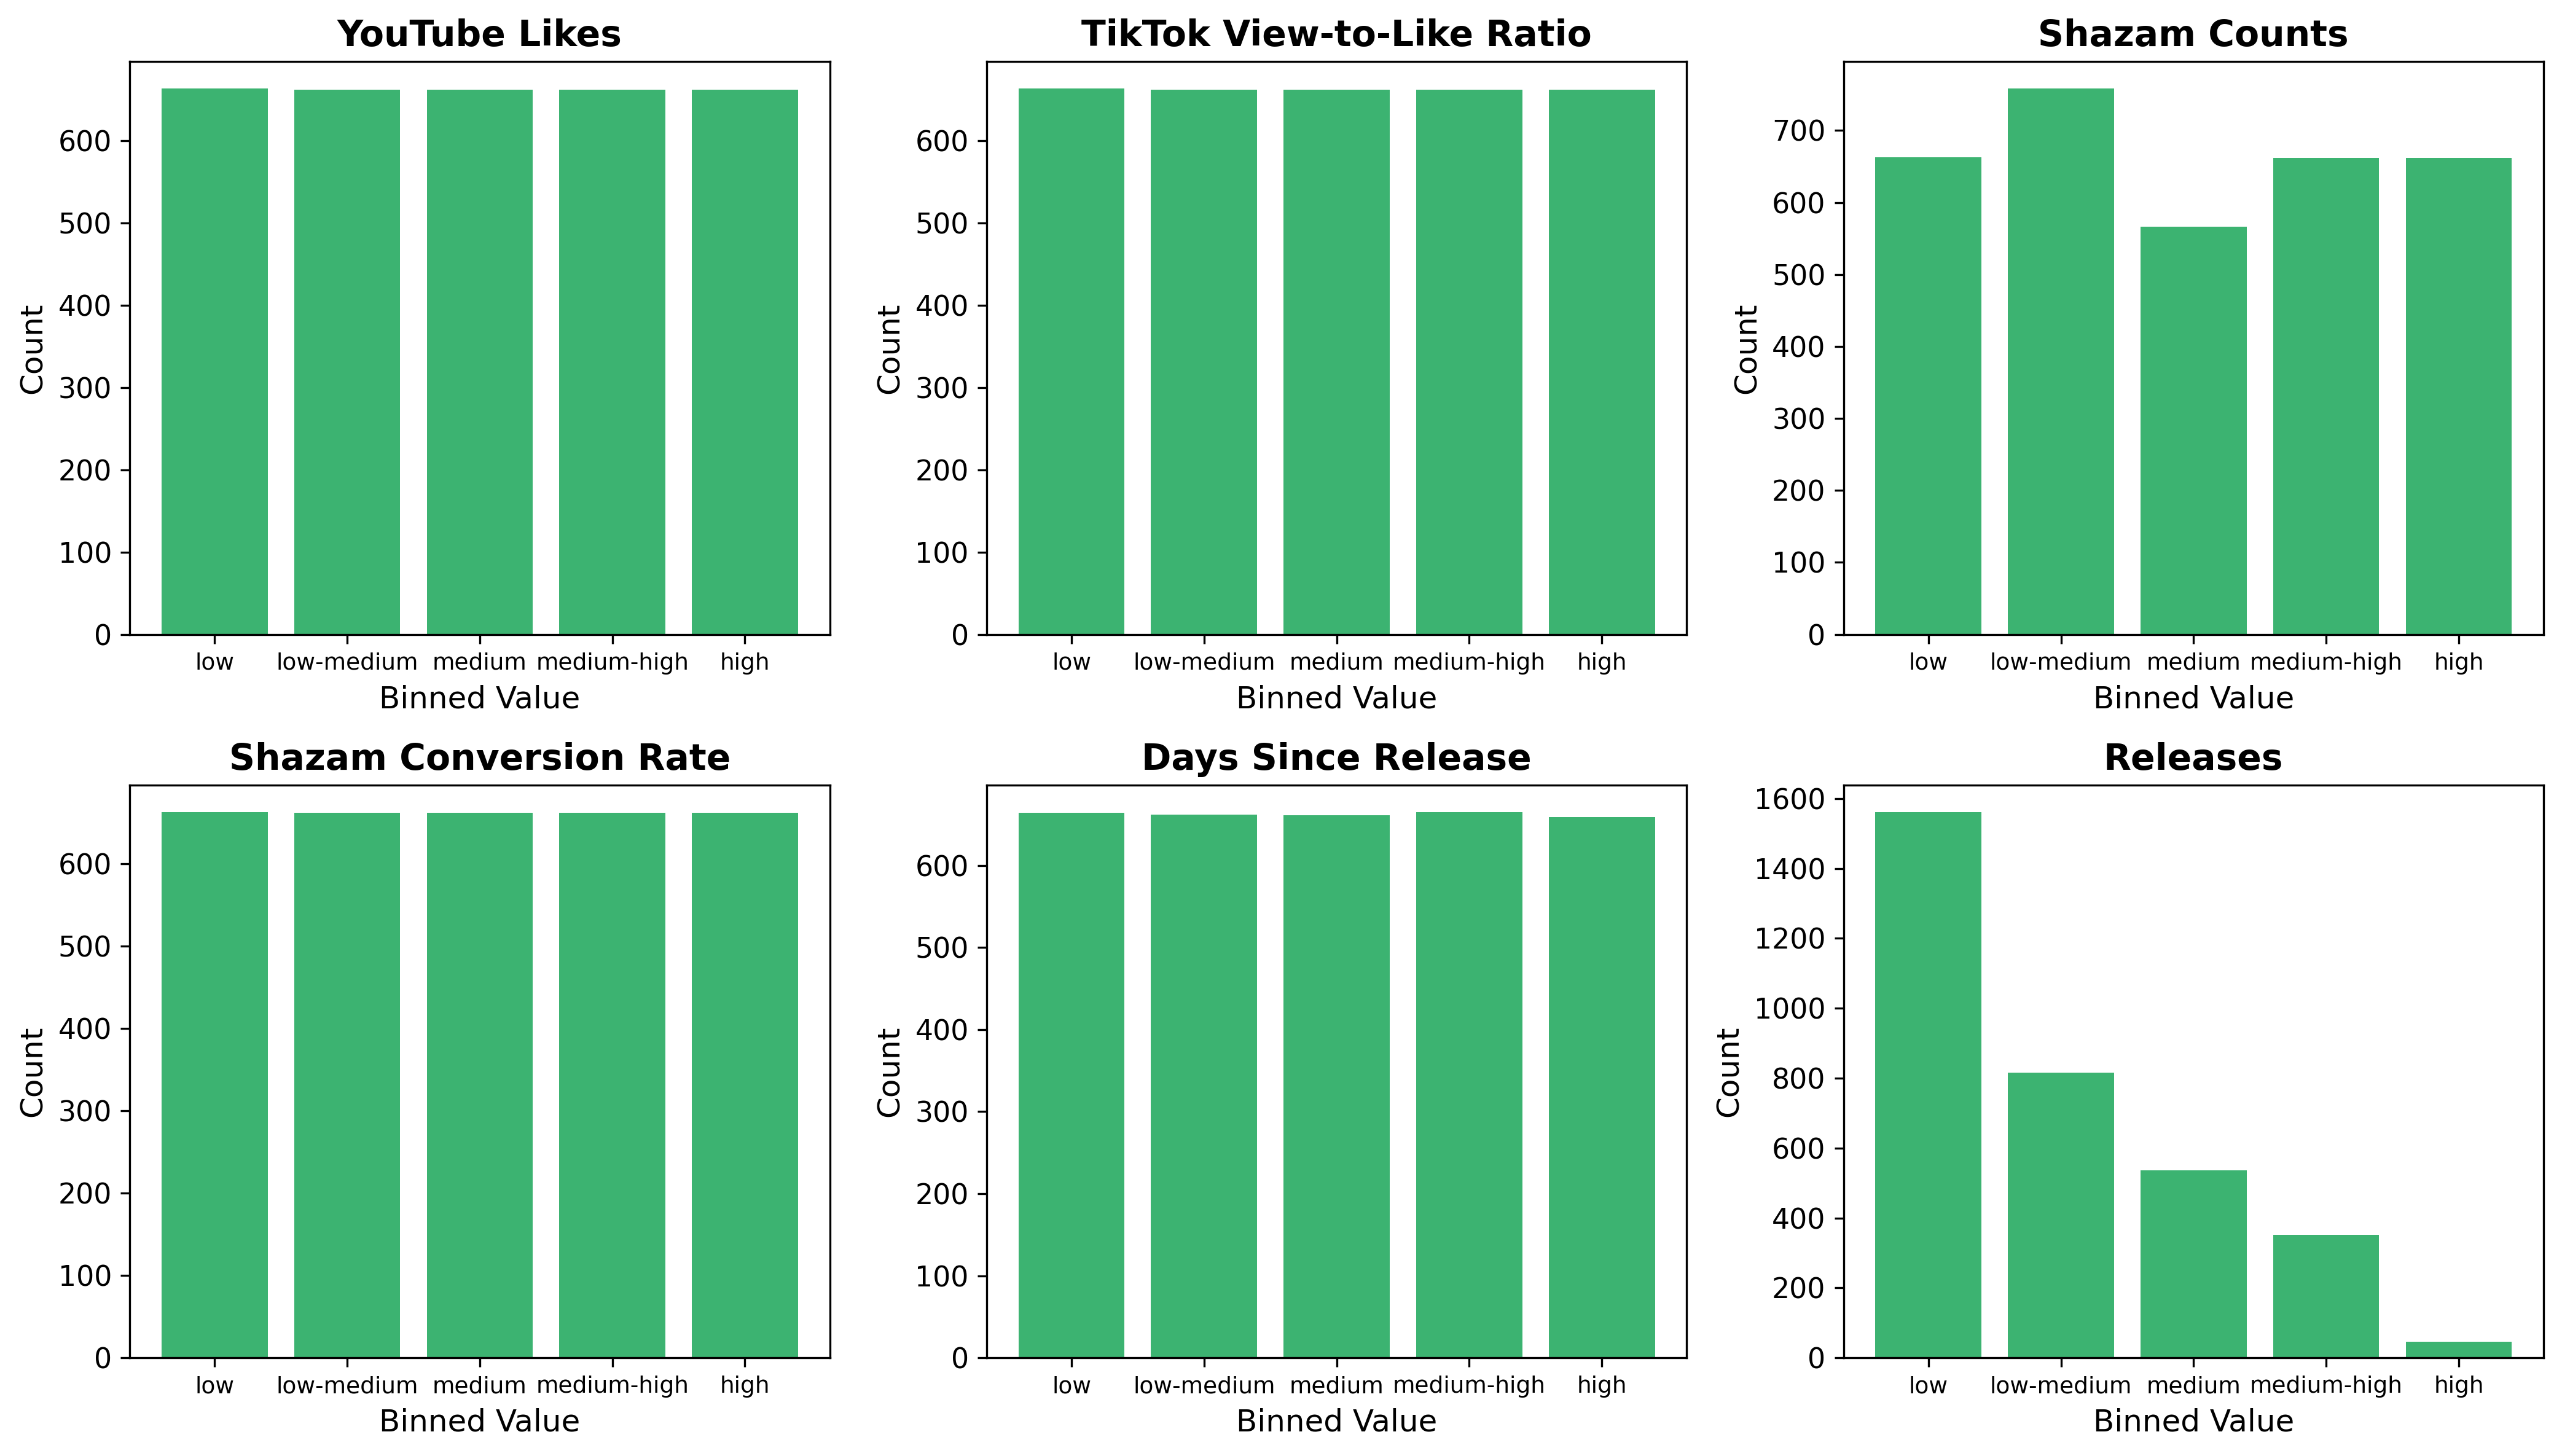

,low,low-medium,medium,medium-high,high,Label
0,3,1,1,1,0,1
1,2,1,1,2,0,1
2,1,1,2,1,1,1
3,0,2,1,1,2,1
4,1,1,2,0,2,1


In [4]:
import numpy as np

# 1. Define Multinomial Naive Bayes dataset
df_mnb = df_nb.copy()

df_mnb['Releases'] = np.log1p(df_mnb['Releases'])

df_mnb_binned = my_count_binner(df_mnb.drop('Label', axis=1))
df_mnb_binned['Label'] = df_mnb['Label']

my_bin_plotter(df_mnb_binned.drop('Label', axis=1))

df_mnb_collapsed = my_count_vectorizer(df_mnb_binned)
df_mnb_collapsed.head()

### Gaussian Naive Bayes

In [5]:
# 1. Define Gaussian Naive Bayes dataset
df_gnb = df_nb.copy()

### Categorical Naive Bayes

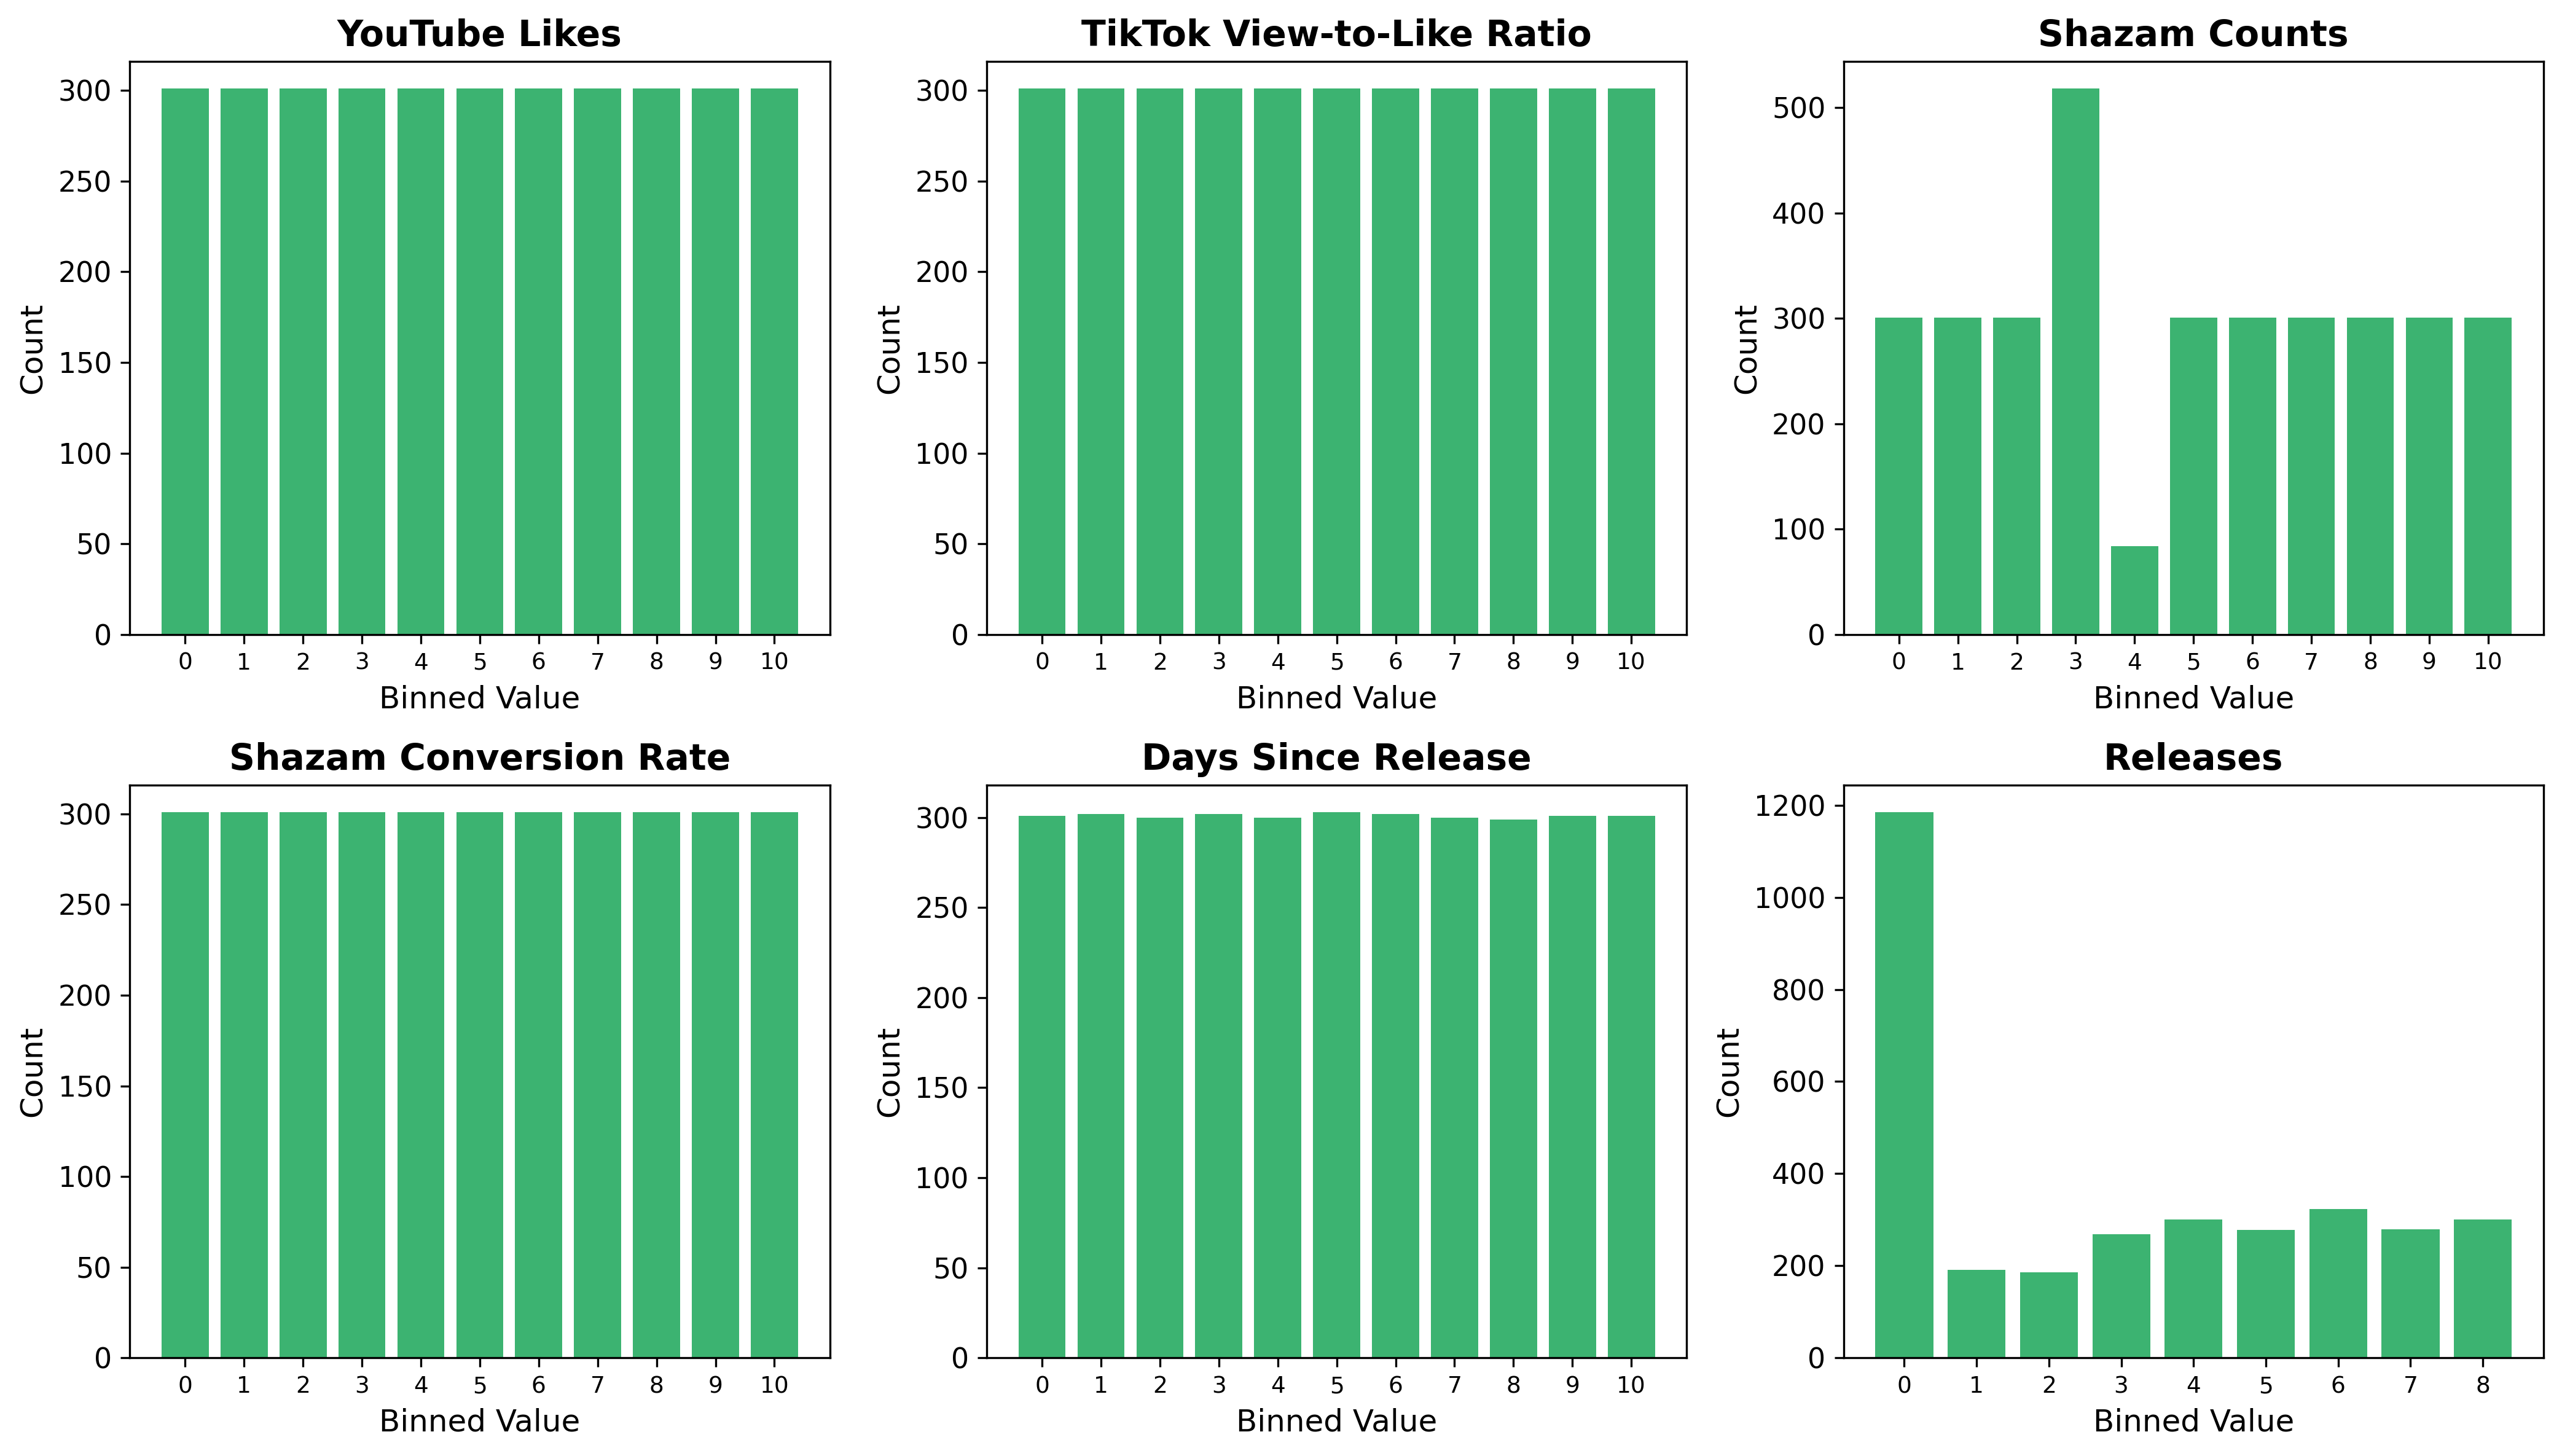

In [6]:
# 1. Define Categorical Naive Bayes dataset
df_cnb = df_nb.copy()

df_cnb_binned = my_binner(df_cnb.drop('Label', axis=1))
df_cnb_binned['Label'] = df_cnb['Label']
    
my_bin_plotter(df_cnb_binned.drop('Label', axis=1))

## Model Data

### Custom classes to reduce code repetition

See file at `./custom_model_prep.py` for the code.

In [7]:
from custom_model_prep import MySplitter, MyScaler, MyResults

### Multinomial Naive Bayes

Training Data: (2648 rows ~80.0%)



,low,low-medium,medium,medium-high,high,Label
507,2,2,1,1,0,1
1338,0,3,2,1,0,1
2965,2,0,3,1,0,1
1479,0,3,1,1,1,1
839,1,0,3,2,0,1


Testing Data: (663 rows ~20.0%)



,low,low-medium,medium,medium-high,high,Label
1317,1,1,4,0,0,0
441,2,1,2,0,1,1
568,0,2,2,1,1,1
1639,0,0,4,1,1,1
357,1,1,1,3,0,1


Feature Names:
['low' 'low-medium' 'medium' 'medium-high' 'high']

Class Names:
['Low', 'High']


Accuracy: 0.7707
Precision: 0.8278
Recall:    0.7956
F1 Score:  0.8114


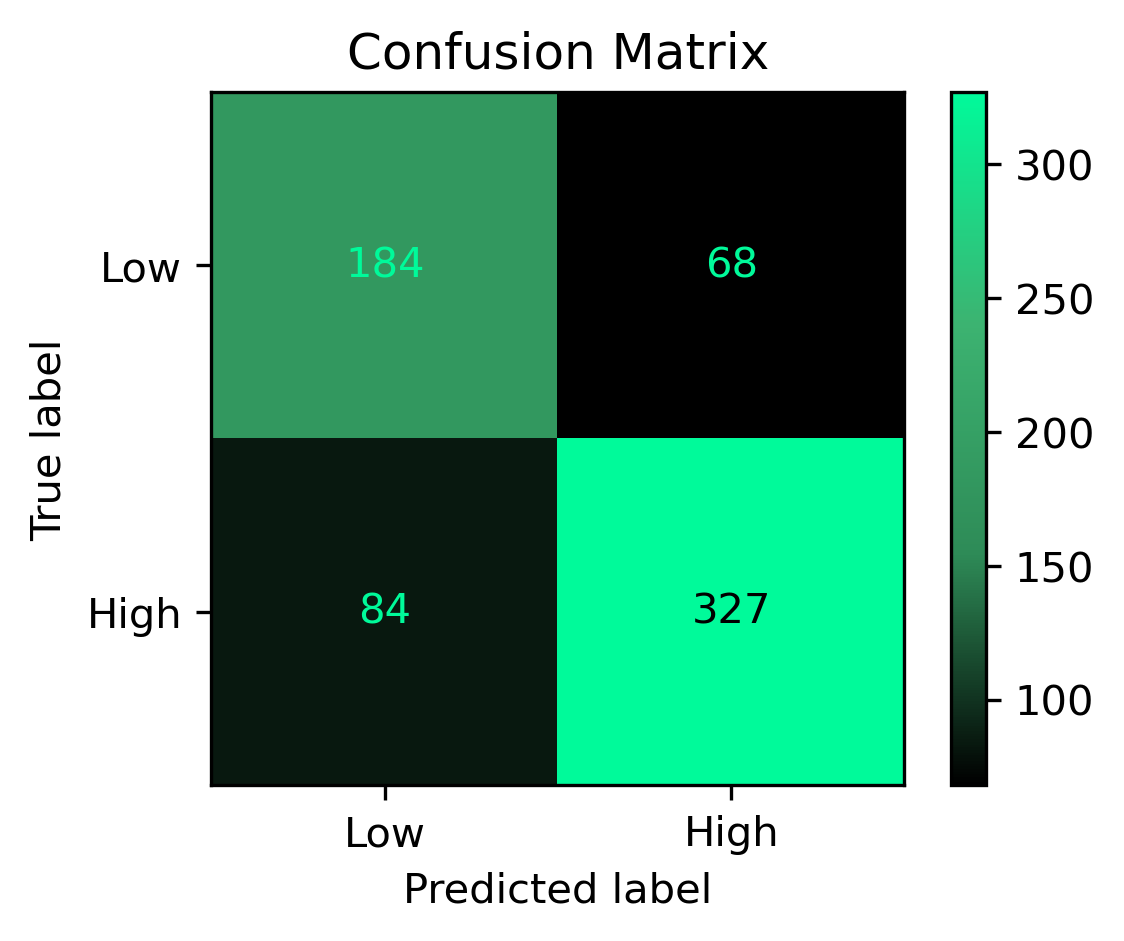

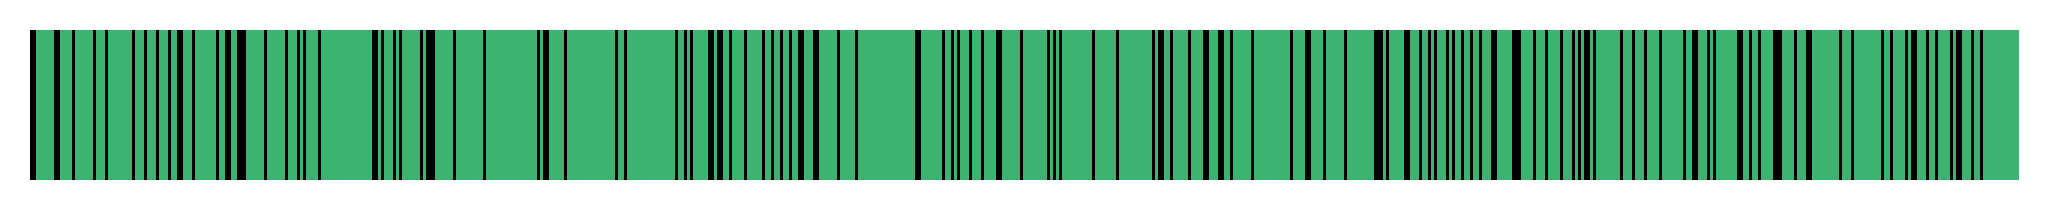

In [8]:
from sklearn.naive_bayes import MultinomialNB


# 2. Splitting
splitter = MySplitter(df_mnb_collapsed)

# -- Train-test split
train_df, test_df = splitter.train_test()
# -- X-y split
train_X, train_y, test_X, test_y, features, classes = splitter.x_y(train_df, test_df)


# 3. Normalization
# -- Counts do not need normalization


# 4. Training
NB = MultinomialNB()
NB.fit(train_X, train_y)


# 5. Prediction
prediction = NB.predict(test_X)


# 6. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()

### Gaussian Naive Bayes

Training Data: (2648 rows ~80.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
507,1117686,10.671368,554474,0.003282,558,2,1
1338,2439195,13.360463,701730,0.000800,1472,5,1
2965,2333652,7.224198,961364,0.003093,1674,1,1
1479,6533684,8.396780,855525,0.000983,2486,39,1
839,1156874,10.873670,1347624,0.003357,632,22,1


Testing Data: (663 rows ~20.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
1317,1213273,9.856405,977339,0.002192,1065,2,0
441,862952,14.516485,1434689,0.001962,694,1,1
568,11144552,9.936439,855525,0.000637,2157,41,1
1639,1790062,9.494025,4522347,0.006620,1598,26,1
357,3626173,8.558971,2592470,0.002937,2249,2,1


Feature Names:
['YouTube Likes' 'TikTok View-to-Like Ratio' 'Shazam Counts'
 'Shazam Conversion Rate' 'Days Since Release' 'Releases']

Class Names:
['Low', 'High']

Log transformed (skewness > 0.5):
['YouTube Likes', 'TikTok View-to-Like Ratio', 'Shazam Counts', 'Shazam Conversion Rate', 'Days Since Release', 'Releases']


Accuracy: 0.7934
Precision: 0.8827
Recall:    0.7689
F1 Score:  0.8218


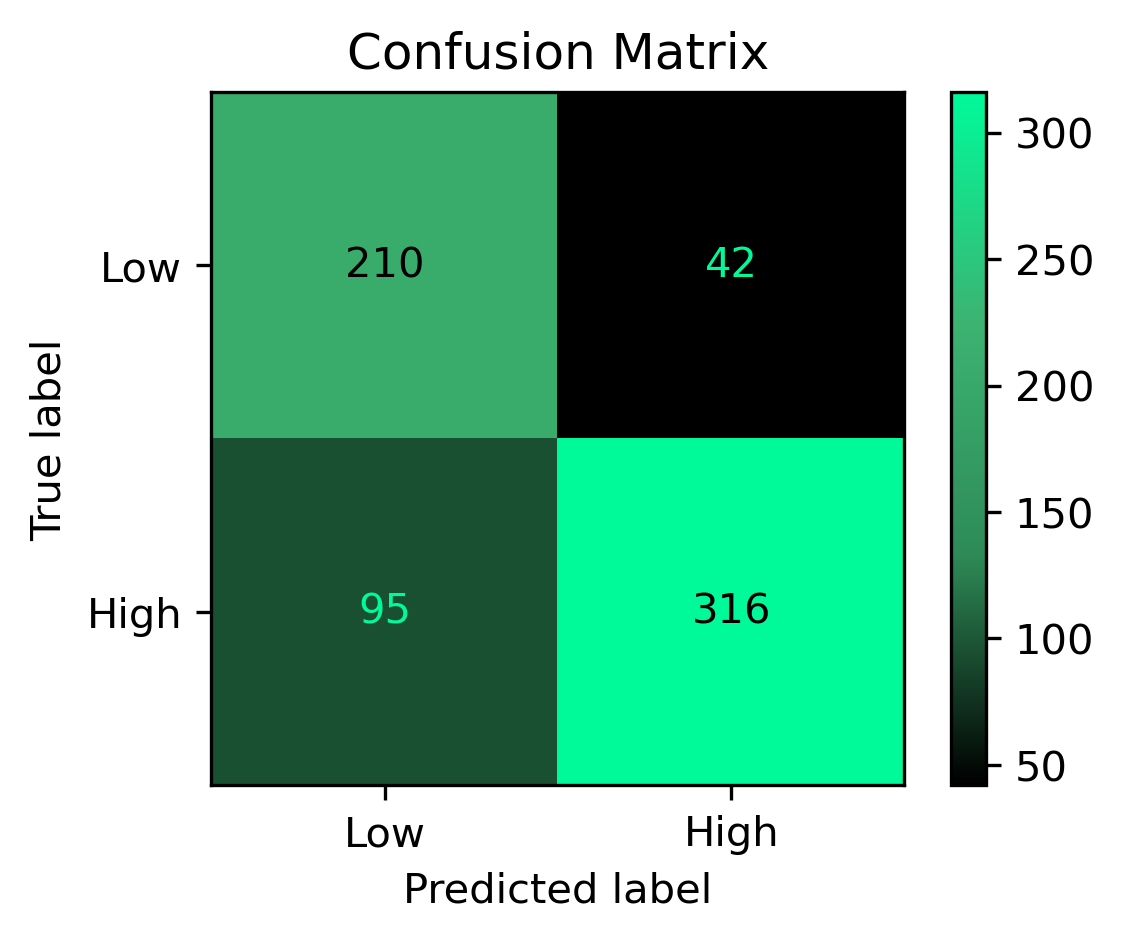

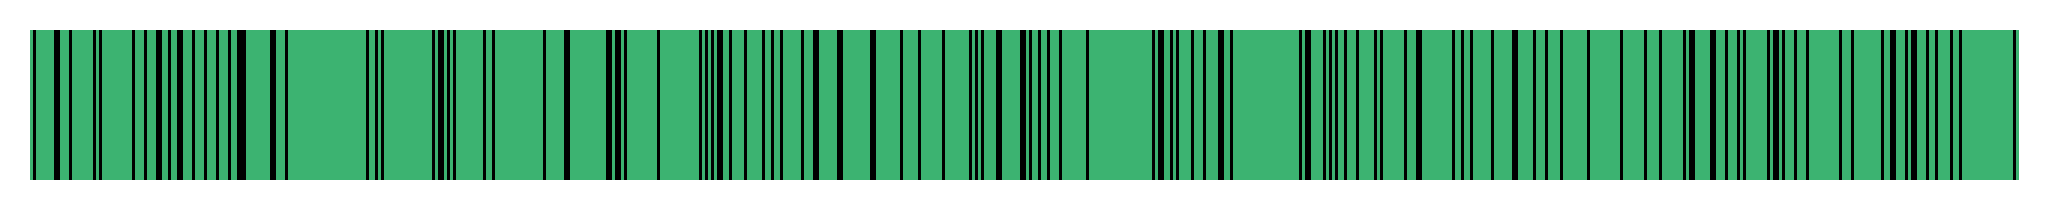

In [9]:
from sklearn.naive_bayes import GaussianNB


# 2. Splitting
splitter = MySplitter(df_gnb)

# -- Train-test split
train_df, test_df = splitter.train_test()
# -- X-y split
train_X, train_y, test_X, test_y, features, classes = splitter.x_y(train_df, test_df)


# 3. Normalization
scaler = MyScaler()

# -- Log transform
train_X, test_X = scaler.log(train_X, test_X)
# -- StandardScaler
train_X, test_X = scaler.standard(train_X, test_X)


# 4. Training
NB = GaussianNB()
NB.fit(train_X, train_y)


# 5. Prediction
prediction = NB.predict(test_X)


# 6. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()

### Categorical Naive Bayes

Training Data: (2648 rows ~80.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
507,4,6,2,6,0,0,1
1338,6,8,3,2,5,3,1
2965,6,1,4,6,6,0,1
1479,9,3,3,3,8,7,1
839,4,6,5,6,1,6,1


Testing Data: (663 rows ~20.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
1317,4,5,5,5,4,0,0
441,3,9,6,5,1,0,1
568,10,5,3,2,7,7,1
1639,5,5,8,8,6,6,1
357,7,4,7,6,7,0,1


Feature Names:
['YouTube Likes' 'TikTok View-to-Like Ratio' 'Shazam Counts'
 'Shazam Conversion Rate' 'Days Since Release' 'Releases']

Class Names:
['Low', 'High']


Accuracy: 0.8084
Precision: 0.8817
Recall:    0.7981
F1 Score:  0.8378


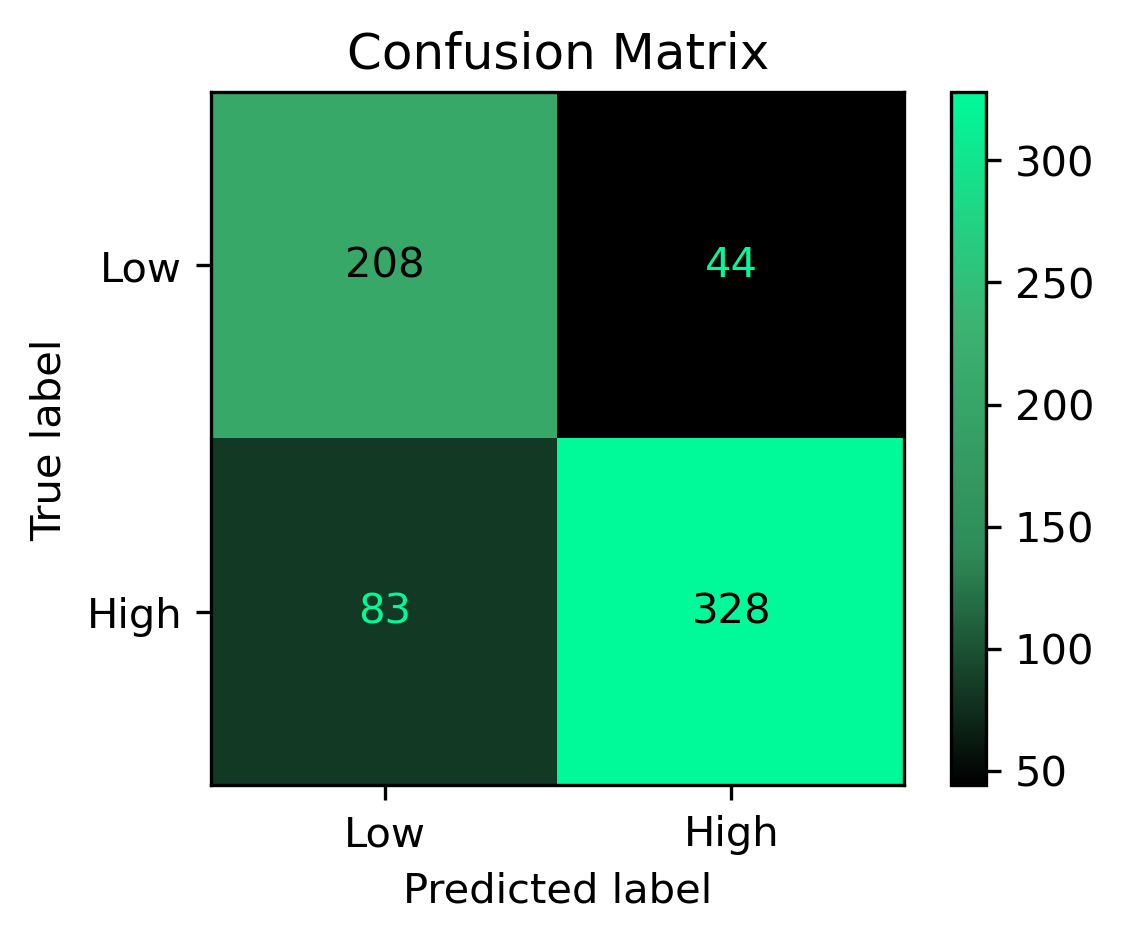

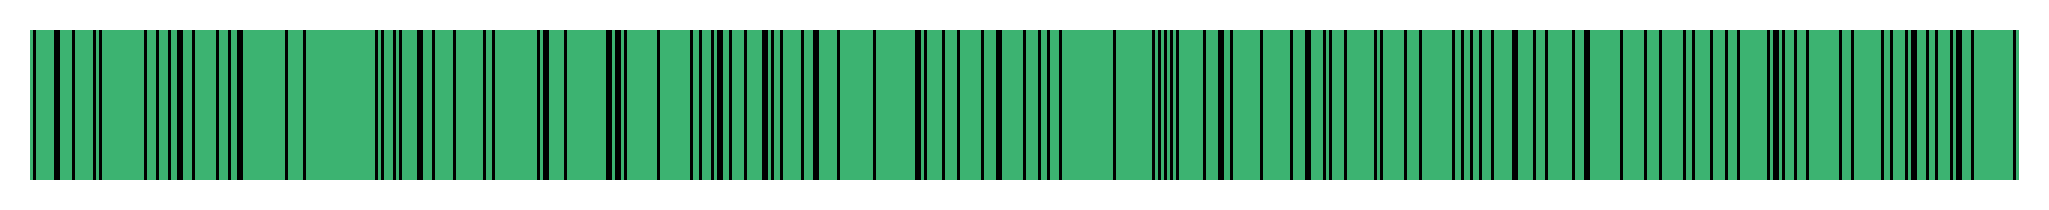

In [10]:
from sklearn.naive_bayes import CategoricalNB


# 2. Splitting
splitter = MySplitter(df_cnb_binned)

# -- Train-test split
train_df, test_df = splitter.train_test()
# -- X-y split
train_X, train_y, test_X, test_y, features, classes = splitter.x_y(train_df, test_df)


# 3. Normalization
# -- Categories are not normalizable


# 4. Training
NB = CategoricalNB()
NB.fit(train_X, train_y)


# 5. Prediction
prediction = NB.predict(test_X)


# 6. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()